# Setting up / importing

In [1]:
import sys

PROJECT_DIR = "/home/565/pv3484/aus_substation_electricity"
sys.path.append(PROJECT_DIR)
%cd {PROJECT_DIR}

/home/565/pv3484/aus_substation_electricity


In [2]:
%run /home/565/pv3484/aus_substation_electricity/import_substation.py

processing nsw substations for ['ausgrid'] from None to None
ausgrid
following columns in demand are not in info index:
['MT_HU', 'SI_NO']
removing these columns from demand
number of substations in ausgrid substation info: 134
number of substations in ausgrid substation data: 132
following sites match selection criteria:
               energy_asset          Name  Area  Dwellings  Persons  Residential  Commercial  Industrial  Primary Production  Education  \
ID                                                                                                                                        
BLAKE         AG_BLAKEHURST    Blakehurst     7      10081    28521        0.850       0.005       0.021               0.000      0.022   
PUNCH          AG_PUNCHBOWL     Punchbowl     9      17514    50395        0.826       0.048       0.038               0.000      0.025   
MEADO         AG_MEADOWBANK    Meadowbank    15      22420    56948        0.825       0.023       0.015               0

In [3]:
import time

import pandas as pd
from dateutil.easter import easter
from geopy.geocoders import Nominatim

RANK_CSV = "/home/565/pv3484/aus_substation_electricity/data/cleaned_data/full_nsw_relative_rank.csv"


def second_monday_of_june(y):
    """Return the date of the second Monday in June for year y (Monarch's Birthday)."""
    june = pd.date_range(start=f"{y}-06-01", end=f"{y}-06-30", freq="D")
    mondays = june[june.weekday == 0]
    return mondays[1]


# NSW public holidays, including Easter (date-calculated each year)
HOLIDAYS_VIC = {
    "New Year's Day":  lambda y: pd.Timestamp(f"{y}-01-01"),
    "Australia Day":   lambda y: pd.Timestamp(f"{y}-01-26"),
    "Good Friday":     lambda y: pd.Timestamp(easter(y)) - pd.Timedelta(days=2),
    "Easter Saturday": lambda y: pd.Timestamp(easter(y)) - pd.Timedelta(days=1),
    "Easter Sunday":   lambda y: pd.Timestamp(easter(y)),
    "Easter Monday":   lambda y: pd.Timestamp(easter(y)) + pd.Timedelta(days=1),
    "ANZAC Day":       lambda y: pd.Timestamp(f"{y}-04-25"),
    "Monarch's Birthday": lambda y: second_monday_of_june(y),
    "Christmas Day":   lambda y: pd.Timestamp(f"{y}-12-25"),
    "Boxing Day":      lambda y: pd.Timestamp(f"{y}-12-26"),
}

holiday_order = list(HOLIDAYS_VIC.keys())

# Maps individual holiday names to their group label
HOLIDAY_GROUPS = {
    "Good Friday":     "Easter Long Weekend",
    "Easter Saturday": "Easter Long Weekend",
    "Easter Sunday":   "Easter Long Weekend",
    "Easter Monday":   "Easter Long Weekend",
    "Christmas Day":   "Christmas and Boxing Day",
    "Boxing Day":      "Christmas and Boxing Day",
}

In [4]:
info.loc[info["Name"] == "Chatswood", "Residential"]

CHATS    0.766
Name: Residential, dtype: float64

In [5]:
rank = pd.read_csv(RANK_CSV)

In [6]:
rank.columns.tolist()

['station_code',
 'holiday_group',
 'year',
 'date',
 '00_04_mean_relative_rank',
 '00_04_std_relative_rank',
 '00_04_var_relative_rank',
 '04_10_mean_relative_rank',
 '04_10_std_relative_rank',
 '04_10_var_relative_rank',
 '10_15_mean_relative_rank',
 '10_15_std_relative_rank',
 '10_15_var_relative_rank',
 '15_20_mean_relative_rank',
 '15_20_std_relative_rank',
 '15_20_var_relative_rank',
 '20_24_mean_relative_rank',
 '20_24_std_relative_rank',
 '20_24_var_relative_rank',
 'is_holiday',
 'weekday_name',
 'is_weekend',
 'energy_asset',
 'Name',
 'Area',
 'Dwellings',
 'Persons',
 'Residential',
 'Commercial',
 'Industrial',
 'Primary Production',
 'Education',
 'Hospital/Medical',
 'Transport',
 'Parkland',
 'Water',
 'Other',
 'latitude',
 'longitude']

## Geocode substations

Look up lat/lon for each substation by suburb name. Results are written back into `info`.
Manually patches **Dee Why West**, which has no polygon in the geocoder.

In [7]:
geolocator = Nominatim(user_agent="sydney_demand_mapper")


def get_coords(place):
    """Return (lat, lon) for a NSW suburb name, or (None, None) if not found."""
    try:
        loc = geolocator.geocode(f"{place}, New South Wales, Australia")
        if loc:
            return loc.latitude, loc.longitude
    except Exception as e:
        print(f"Geocoding failed for {place}: {e}")
    return None, None


latitudes, longitudes = [], []
for suburb in info["Name"]:
    lat, lon = get_coords(suburb)
    latitudes.append(lat)
    longitudes.append(lon)
    time.sleep(1)  # respect Nominatim rate limit

info["latitude"] = latitudes
info["longitude"] = longitudes

In [8]:
# Check which stations failed to geocode
missing = info[info["latitude"].isna() | info["longitude"].isna()]
missing["Name"].unique()

array(['Dee Why West'], dtype=object)

In [9]:
# Dee Why West has no suburb polygon — patch with manually sourced coordinates
info.loc[info["Name"] == "Dee Why West", "latitude"] = -33.73441
info.loc[info["Name"] == "Dee Why West", "longitude"] = 151.28278

## Map mean relative rank differences

Three-panel map showing, for each high-residential substation:
- **Panel 1** – Public holiday mean relative rank (binned, plasma palette)
- **Panel 2** – PH minus weekend (separate scale, RdBu_r)
- **Panel 3** – PH minus weekday (separate scale, PuOr_r)

In [10]:
import geopandas as gpd
import matplotlib
import matplotlib.pyplot as plt
import contextily as ctx
import numpy as np
import pathlib
import pandas as pd
from matplotlib.colors import ListedColormap

BLOCK_LABELS = {
    "00_04": "00:00–04:00",
    "04_10": "04:00–10:00",
    "10_15": "10:00–15:00",
    "15_20": "15:00–20:00",
    "20_24": "20:00–00:00",
}

ALL_BLOCKS = list(BLOCK_LABELS.keys())

HOLIDAY_BATCH = [
    ("New Year's Day",           ["New Year's Day"]),
    ("Australia Day",            ["Australia Day"]),
    ("Easter Long Weekend",      ["Good Friday", "Easter Saturday", "Easter Sunday", "Easter Monday"]),
    ("ANZAC Day",                ["ANZAC Day"]),
    ("Queen's Birthday",         ["Monarch's Birthday"]),
    ("Christmas and Boxing Day", ["Christmas Day", "Boxing Day"]),
]

FIG_ROOT = pathlib.Path(
    "/home/565/pv3484/aus_substation_electricity/data/figures"
    "/mrr_pb_minus_we_wd/separate_scale_new_scale"
)


def map_ph_we_wd_block_combined(
    df,
    info,
    holidays,
    holiday_group_name,
    block,
    we_diff_min=None,
    we_diff_max=None,
    wd_diff_min=None,
    wd_diff_max=None,
    df_station_col="Name",
    info_station_col="Name",
    lat_col="latitude",
    lon_col="longitude",
    residential_col="Residential",
    residential_threshold=0.75,
    block_suffix="_mean_relative_rank",
    crs_epsg=3857,
    wd_diff_cmap="PuOr_r",
):
    """Three-panel map of public holiday relative demand vs. weekends and weekdays.

    Parameters
    ----------
    df : DataFrame
        Relative rank data (one row per station-date).
    info : DataFrame
        Substation metadata including lat/lon and land-use fractions.
    holidays : list[str]
        Holiday names to treat as the public holiday group.
    holiday_group_name : str
        Display name for the holiday group (used in the title).
    block : str
        Time block key, e.g. ``"10_15"``.
    we_diff_min, we_diff_max : float, optional
        Colour scale limits for the PH−weekend panel. Auto-symmetrised if omitted.
    wd_diff_min, wd_diff_max : float, optional
        Colour scale limits for the PH−weekday panel. Auto-symmetrised if omitted.
    """
    block_label = BLOCK_LABELS.get(block, block)

    # --- Eligible stations: high-residential, with data, excluding Umina ---
    high_res = info[
        (info[residential_col] >= residential_threshold)
        & (info[info_station_col] != "Umina")
    ][info_station_col]

    block_cols = [f"{b}{block_suffix}" for b in ALL_BLOCKS]
    stations_with_data = (
        df.groupby(df_station_col)[block_cols]
        .apply(lambda x: x.notna().any().any())
    )
    stations_with_data = stations_with_data[stations_with_data].index
    eligible_stations = set(high_res).intersection(stations_with_data)

    df = df[df[df_station_col].isin(eligible_stations)].copy()
    df_hol = df[df["holiday_group"].isin(holidays)].copy()

    # --- GeoDataFrame ---
    gdf = info[info[info_station_col].isin(eligible_stations)].copy()
    gdf = gpd.GeoDataFrame(
        gdf,
        geometry=gpd.points_from_xy(gdf[lon_col], gdf[lat_col]),
        crs="EPSG:4326",
    ).to_crs(crs_epsg)

    # --- Compute PH, PH−WE, PH−WD per station ---
    col = f"{block}{block_suffix}"
    results = []

    for station in eligible_stations:
        df_s = df_hol[df_hol[df_station_col] == station]

        if df_s.empty or df_s[col].isna().all():
            results.append({info_station_col: station, "ph": np.nan, "ph_we": np.nan, "ph_wd": np.nan})
            continue

        df_station_all = df[df[df_station_col] == station]

        ph_val = df_s[df_s["is_holiday"]][col].mean()
        we_val = df_station_all[~df_station_all["is_holiday"] & df_station_all["is_weekend"]][col].mean()
        wd_val = df_station_all[~df_station_all["is_holiday"] & ~df_station_all["is_weekend"]][col].mean()

        results.append({
            info_station_col: station,
            "ph":    ph_val,
            "ph_we": ph_val - we_val if pd.notna(ph_val) and pd.notna(we_val) else np.nan,
            "ph_wd": ph_val - wd_val if pd.notna(ph_val) and pd.notna(wd_val) else np.nan,
        })

    gdf = gdf.merge(pd.DataFrame(results), on=info_station_col, how="left")

    # Guard against empty data
    if gdf["ph"].isna().all():
        plt.close("all")
        raise ValueError(f"No data for holiday='{holiday_group_name}', block='{block}'")

    # --- PH bins and plasma palette ---
    bins = [0.00, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]
    bin_labels = [f"{bins[i]:.2f}–{bins[i+1]:.2f}" for i in range(len(bins) - 1)]

    gdf["ph_clipped"] = gdf["ph"].clip(lower=bins[0], upper=bins[-1])
    gdf["ph_bin"] = pd.cut(gdf["ph_clipped"], bins=bins, labels=bin_labels, include_lowest=True)

    plasma = matplotlib.colormaps.get_cmap("plasma")
    ph_colors = [plasma(p) for p in np.linspace(0, 1, len(bin_labels)) ** 0.7]
    ph_cmap = ListedColormap(ph_colors)

    # --- Auto-symmetrise difference scales if not provided ---
    if we_diff_min is None:
        abs_we = max(abs(gdf["ph_we"].min()), abs(gdf["ph_we"].max()))
        we_diff_min, we_diff_max = -abs_we, abs_we
    if wd_diff_min is None:
        abs_wd = max(abs(gdf["ph_wd"].min()), abs(gdf["ph_wd"].max()))
        wd_diff_min, wd_diff_max = -abs_wd, abs_wd

    # --- Map extent with padding ---
    minx, miny, maxx, maxy = gdf.total_bounds
    pad = 4800
    extent = (minx - pad, maxx + pad, miny - pad, maxy + pad)

    # --- Plotting ---
    fig, axes = plt.subplots(1, 3, figsize=(20, 7))
    for ax in axes:
        ax.set_aspect("equal", adjustable="box")

    year_min = int(df_hol["year"].min()) if not df_hol.empty else "?"
    year_max = int(df_hol["year"].max()) if not df_hol.empty else "?"

    fig.suptitle(
        f"Relative Demand Patterns ({holiday_group_name}) "
        f"({block_label}, {year_min}–{year_max})\n"
        f"High-residential locations only (≥ {residential_threshold})",
        fontsize=17, y=0.999,
    )

    title_y = 0.99
    axes[0].set_title("Public Holiday Relative Rank (binned)", y=title_y)
    axes[1].set_title("Public Holiday − Weekend Mean Relative Rank", y=title_y)
    axes[2].set_title("Public Holiday − Weekday Mean Relative Rank", y=title_y)

    MARKER_KWARGS = dict(markersize=70, edgecolor="black", legend=False,
                         missing_kwds={"color": "#e6e6e6", "label": "No data"})

    # Panel 1: PH binned
    gdf.plot(ax=axes[0], column="ph_bin", cmap=ph_cmap, **MARKER_KWARGS)

    handles = [
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=ph_colors[i], markersize=10)
        for i in range(len(bin_labels))
    ]
    handles.append(
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="#e6e6e6", markersize=10, label="No data")
    )
    fig.legend(
        handles, bin_labels + ["No data"],
        title="Public Holiday Relative Rank (binned)\n(values > 0.60 clipped to top bin)",
        loc="center left", bbox_to_anchor=(0.005, 0.50), frameon=False, fontsize=8,
    )

    # Panel 2: PH − Weekend
    gdf.plot(ax=axes[1], column="ph_we", cmap="RdBu_r", vmin=we_diff_min, vmax=we_diff_max, **MARKER_KWARGS)
    sm_we = plt.cm.ScalarMappable(cmap="RdBu_r", norm=plt.Normalize(vmin=we_diff_min, vmax=we_diff_max))
    sm_we._A = []
    fig.colorbar(sm_we, ax=axes[1], orientation="horizontal", fraction=0.05, pad=0.02).set_label(
        f"PH − Weekend ({we_diff_min:.2f} to {we_diff_max:.2f})"
    )

    # Panel 3: PH − Weekday
    gdf.plot(ax=axes[2], column="ph_wd", cmap=wd_diff_cmap, vmin=wd_diff_min, vmax=wd_diff_max, **MARKER_KWARGS)
    sm_wd = plt.cm.ScalarMappable(cmap=wd_diff_cmap, norm=plt.Normalize(vmin=wd_diff_min, vmax=wd_diff_max))
    sm_wd._A = []
    fig.colorbar(sm_wd, ax=axes[2], orientation="horizontal", fraction=0.05, pad=0.02).set_label(
        f"PH − Weekday ({wd_diff_min:.2f} to {wd_diff_max:.2f})"
    )

    # Basemap and station labels
    for ax in axes:
        ax.set_xlim(extent[0], extent[1])
        ax.set_ylim(extent[2], extent[3])
        ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
        for _, row in gdf.iterrows():
            ax.text(row.geometry.x + 800, row.geometry.y, row[info_station_col],
                    fontsize=8, ha="left", va="center")
        ax.set_axis_off()

    plt.subplots_adjust(top=0.86, bottom=0.16, wspace=0.08, hspace=0.01)
    return fig


def compute_global_diff_scales(df, holiday_batch, block_suffix="_mean_relative_rank",
                                df_station_col="Name"):
    """Compute symmetric colour scale limits for PH−WE and PH−WD across all holidays and blocks."""
    all_we, all_wd = [], []

    for _, holidays in holiday_batch:
        df_hol = df[df["holiday_group"].isin(holidays)]

        for block in ALL_BLOCKS:
            col = f"{block}{block_suffix}"

            for station in df[df_station_col].unique():
                df_s = df_hol[df_hol[df_station_col] == station]
                df_all = df[df[df_station_col] == station]

                ph_val = df_s[df_s["is_holiday"]][col].mean() if not df_s.empty else np.nan
                we_val = df_all[~df_all["is_holiday"] & df_all["is_weekend"]][col].mean()
                wd_val = df_all[~df_all["is_holiday"] & ~df_all["is_weekend"]][col].mean()

                if pd.notna(ph_val) and pd.notna(we_val):
                    all_we.append(ph_val - we_val)
                if pd.notna(ph_val) and pd.notna(wd_val):
                    all_wd.append(ph_val - wd_val)

    abs_we = max(abs(min(all_we)), abs(max(all_we)))
    abs_wd = max(abs(min(all_wd)), abs(max(all_wd)))

    return (-abs_we, abs_we), (-abs_wd, abs_wd)


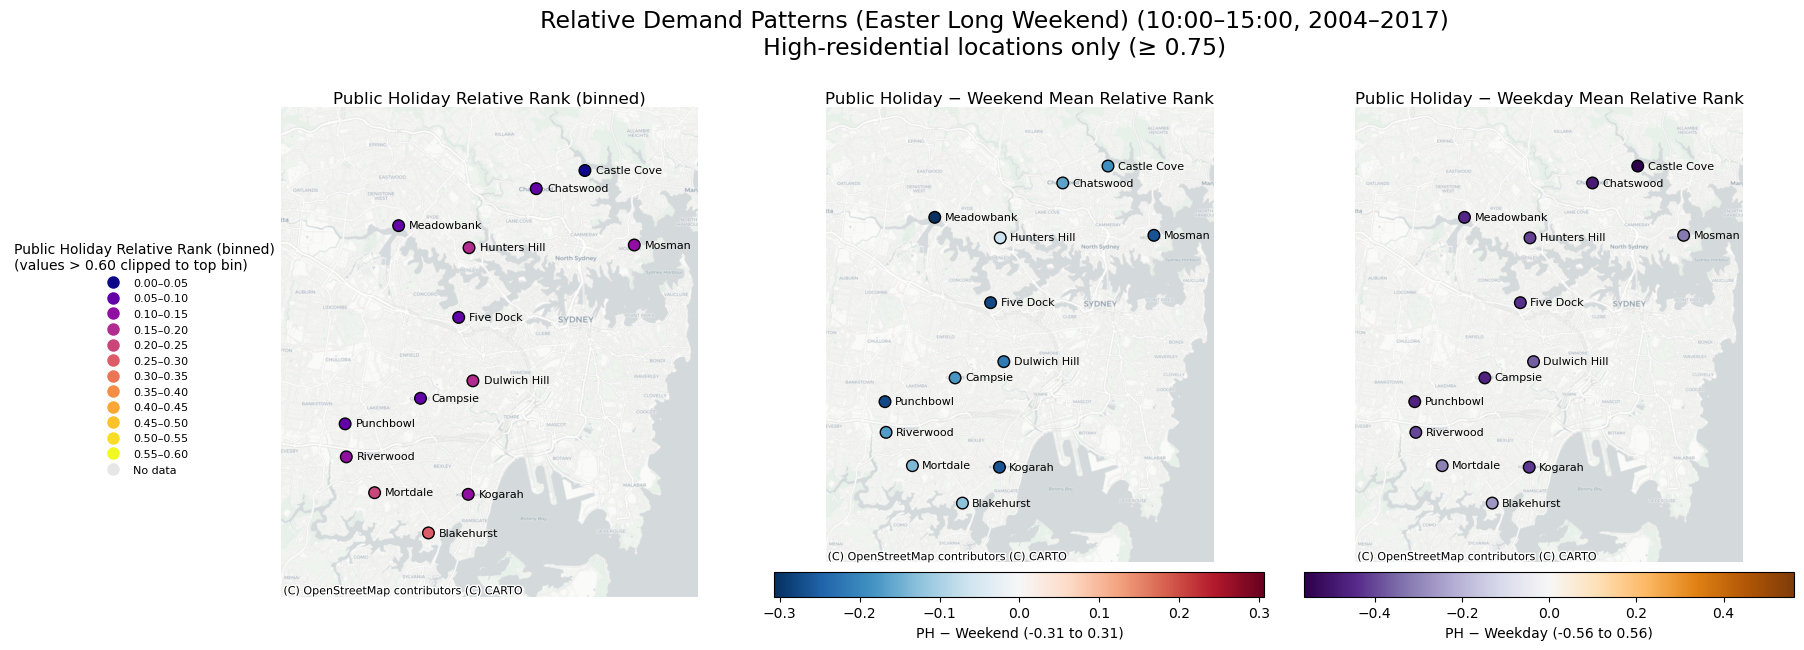

In [11]:
fig = map_ph_we_wd_block_combined(
    df=rank,
    info=info,
    holidays=["Easter Long Weekend"],
    holiday_group_name="Easter Long Weekend",
    block="10_15",
)
plt.show()

## looping and saving

In [12]:
def batch_export_mrr_maps(df, info, holiday_batch=HOLIDAY_BATCH, fig_root=FIG_ROOT):
    """Generate and save one PNG per holiday group × time block.

    Output layout::

        <fig_root>/<Holiday Group Name>/<block>.png
    """
    (we_min, we_max), (wd_min, wd_max) = compute_global_diff_scales(df, holiday_batch)
    print(f"Global scales — PH−WE: [{we_min:.3f}, {we_max:.3f}]  PH−WD: [{wd_min:.3f}, {wd_max:.3f}]")

    total = len(holiday_batch) * len(ALL_BLOCKS)
    done = 0

    for group_name, holidays in holiday_batch:
        folder_name = group_name.replace("/", "-").replace("'", "")
        out_dir = fig_root / folder_name
        out_dir.mkdir(parents=True, exist_ok=True)

        for block in ALL_BLOCKS:
            out_path = out_dir / f"{block}.png"
            try:
                fig = map_ph_we_wd_block_combined(
                    df=df,
                    info=info,
                    holidays=holidays,
                    holiday_group_name=group_name,
                    block=block,
                    we_diff_min=we_min,
                    we_diff_max=we_max,
                    wd_diff_min=wd_min,
                    wd_diff_max=wd_max,
                )
            except ValueError as e:
                print(f"  [SKIP] {e}")
                done += 1
                continue

            fig.savefig(out_path, dpi=150, bbox_inches="tight")
            plt.close(fig)
            done += 1
            print(f"[{done}/{total}] Saved: {out_path}")

    print("\nDone.")

In [13]:
# batch_export_mrr_maps(df=rank, info=info)

# Using discrete bins for panels 2 and 3 rather than continuous scale bars

In [14]:
from matplotlib.colors import BoundaryNorm

FIG_ROOT_SEMINAR = pathlib.Path(
    "/home/565/pv3484/aus_substation_electricity/data/figures/seminar_difference_maps"
)

def map_ph_we_wd_block_combined_discrete(
    df,
    info,
    holidays,
    holiday_group_name,
    block,
    df_station_col="Name",
    info_station_col="Name",
    lat_col="latitude",
    lon_col="longitude",
    residential_col="Residential",
    residential_threshold=0.75,
    block_suffix="_mean_relative_rank",
    crs_epsg=3857,
):
    """Three-panel map with fixed discrete colour bars on panels 2 and 3.

    Panel 1 : Public Holiday Relative Rank (binned plasma, vertical colourbar)
    Panel 2 : PH minus Weekend mean  (RdBu_r, fixed +/-0.40, 0.10 bins)
    Panel 3 : PH minus Weekday mean  (PuOr_r, fixed +/-0.60, 0.10 bins)

    Each colourbar carries a vertical label describing its metric.
    Figure title shows the holiday group name and formatted time block.
    Stations listed in highlight_stations are drawn with a bold ring.

    Returns
    -------
    fig : matplotlib.figure.Figure
    gdf : GeoDataFrame with computed ph / ph_we / ph_wd columns
    """
    # ---- Automatic holiday-group expansion ----
    if isinstance(holidays, str):
        holidays = [h for h, g in HOLIDAY_GROUPS.items() if g == holidays]

    expanded = []
    for h in holidays:
        if h in HOLIDAY_GROUPS.values():
            expanded.extend([hh for hh, g in HOLIDAY_GROUPS.items() if g == h])
        else:
            expanded.append(h)
    holidays = expanded

    # ---- Rename Monarch's Birthday -> Queen's Birthday in data ----
    df = df.copy()
    df["holiday_group"] = df["holiday_group"].replace(
        {"Monarch's Birthday": "Queen's Birthday"}
    )

    # ---- Fixed global colour-scale ranges ----
    WE_MIN, WE_MAX, WE_STEP = -0.40, 0.40, 0.10
    WD_MIN, WD_MAX, WD_STEP = -0.60, 0.60, 0.10

    # ---- Compute PH / PH-WE / PH-WD BEFORE filtering stations ----
    block_cols = [f"{b}{block_suffix}" for b in ALL_BLOCKS]
    col = f"{block}{block_suffix}"
    block_label = BLOCK_LABELS.get(block, block)

    df_hol_full = df[df["holiday_group"].isin(holidays)].copy()

    results = []
    for station in df[df_station_col].unique():
        df_s   = df_hol_full[df_hol_full[df_station_col] == station]
        df_all = df[df[df_station_col] == station]

        if df_s.empty or df_s[col].isna().all():
            results.append({info_station_col: station,
                             "ph": np.nan, "ph_we": np.nan, "ph_wd": np.nan})
            continue

        ph_val = df_s[df_s["is_holiday"]][col].mean()
        we_val = df_all[~df_all["is_holiday"] &  df_all["is_weekend"]][col].mean()
        wd_val = df_all[~df_all["is_holiday"] & ~df_all["is_weekend"]][col].mean()

        results.append({
            info_station_col: station,
            "ph":    ph_val,
            "ph_we": ph_val - we_val if pd.notna(ph_val) and pd.notna(we_val) else np.nan,
            "ph_wd": ph_val - wd_val if pd.notna(ph_val) and pd.notna(wd_val) else np.nan,
        })

    results_df = pd.DataFrame(results)

    # ---- Filter to high-residential stations with data ----
    high_res = info[
        (info[residential_col] >= residential_threshold)
        & (info[info_station_col] != "Umina")
    ][info_station_col]

    stations_with_data = (
        df.groupby(df_station_col)[block_cols]
          .apply(lambda x: x.notna().any().any())
    )
    stations_with_data = stations_with_data[stations_with_data].index
    eligible_stations  = set(high_res).intersection(stations_with_data)

    results_df = results_df[results_df[info_station_col].isin(eligible_stations)]
    gdf = info[info[info_station_col].isin(eligible_stations)].copy()
    gdf = gdf.merge(results_df, on=info_station_col, how="left")

    # ---- GeoDataFrame ----
    gdf = gpd.GeoDataFrame(
        gdf,
        geometry=gpd.points_from_xy(gdf[lon_col], gdf[lat_col]),
        crs="EPSG:4326",
    ).to_crs(crs_epsg)

    # ---- Panel 1: PH bins (plasma) ----
    bins_ph    = [0.00, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]
    bin_labels = [f"{bins_ph[i]:.2f}-{bins_ph[i+1]:.2f}" for i in range(len(bins_ph) - 1)]

    gdf["ph_clipped"] = gdf["ph"].clip(lower=bins_ph[0], upper=bins_ph[-1])
    gdf["ph_bin"] = pd.cut(gdf["ph_clipped"], bins=bins_ph,
                            labels=bin_labels, include_lowest=True)

    plasma    = matplotlib.colormaps.get_cmap("plasma")
    ph_colors = [plasma(p) for p in np.linspace(0, 1, len(bin_labels)) ** 0.7]
    ph_cmap   = ListedColormap(ph_colors)

    # ---- Discrete bins for panels 2 & 3 ----
    we_bounds  = np.round(np.arange(WE_MIN, WE_MAX + WE_STEP, WE_STEP), 10)
    wd_bounds  = np.round(np.arange(WD_MIN, WD_MAX + WD_STEP, WD_STEP), 10)

    we_base    = matplotlib.colormaps.get_cmap("RdBu_r")
    wd_base    = matplotlib.colormaps.get_cmap("PuOr_r")
    we_listed  = ListedColormap([we_base(i / (len(we_bounds) - 2)) for i in range(len(we_bounds) - 1)])
    wd_listed  = ListedColormap([wd_base(i / (len(wd_bounds) - 2)) for i in range(len(wd_bounds) - 1)])
    we_norm    = BoundaryNorm(we_bounds, len(we_bounds) - 1)
    wd_norm    = BoundaryNorm(wd_bounds, len(wd_bounds) - 1)

    # ---- Map extent ----
    minx, miny, maxx, maxy = gdf.total_bounds
    pad    = 4800
    extent = (minx - pad, maxx + pad, miny - pad, maxy + pad)

    # ---- Figure ----
    fig, axes = plt.subplots(1, 3, figsize=(20, 7))
    for ax in axes:
        ax.set_aspect("equal", adjustable="box")

    # ---- Figure-level title: holiday group + time block + year range ----
    year_min = int(df_hol_full["year"].min()) if not df_hol_full.empty else "?"
    year_max = int(df_hol_full["year"].max()) if not df_hol_full.empty else "?"
    fig.suptitle(
        f"{holiday_group_name}  |  {block_label}  ({year_min}–{year_max})",
        fontsize=16, fontweight="bold", y=1.01,
    )

    axes[0].set_title("Public Holiday Relative Rank", y=0.99)
    axes[1].set_title("Difference from Weekend Mean", y=0.99)
    axes[2].set_title("Difference from Weekday Mean", y=0.99)

    MARKER_KWARGS = dict(
        markersize=70,
        edgecolor="black",
        legend=False,
        missing_kwds={"color": "#e6e6e6", "label": "No data"},
    )

    # Panel 1
    gdf.plot(ax=axes[0], column="ph_bin", cmap=ph_cmap, **MARKER_KWARGS)
    sm_ph = plt.cm.ScalarMappable(cmap=ph_cmap)
    sm_ph._A = []
    cb0 = fig.colorbar(sm_ph, ax=axes[0], orientation="vertical",
                       fraction=0.046, pad=0.02, location="left",
                       boundaries=bins_ph, ticks=bins_ph)
    cb0.set_label("Mean Relative Rank", fontsize=8)

    # Panel 2
    gdf.plot(ax=axes[1], column="ph_we", cmap=we_listed, norm=we_norm, **MARKER_KWARGS)
    sm_we = plt.cm.ScalarMappable(cmap=we_listed, norm=we_norm)
    sm_we._A = []
    cb1 = fig.colorbar(sm_we, ax=axes[1], orientation="vertical",
                       fraction=0.046, pad=0.02, location="left",
                       boundaries=we_bounds, ticks=we_bounds)
    cb1.set_label("Difference in Mean Relative Rank", fontsize=8)

    # Panel 3
    gdf.plot(ax=axes[2], column="ph_wd", cmap=wd_listed, norm=wd_norm, **MARKER_KWARGS)
    sm_wd = plt.cm.ScalarMappable(cmap=wd_listed, norm=wd_norm)
    sm_wd._A = []
    cb2 = fig.colorbar(sm_wd, ax=axes[2], orientation="vertical",
                       fraction=0.046, pad=0.02, location="left",
                       boundaries=wd_bounds, ticks=wd_bounds)
    cb2.set_label("Difference in Mean Relative Rank", fontsize=8)

    # ---- Basemap + labels ----
    for ax in axes:
        ax.set_xlim(extent[0], extent[1])
        ax.set_ylim(extent[2], extent[3])
        ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
        for _, row in gdf.iterrows():
            ax.text(row.geometry.x + 800, row.geometry.y, row[info_station_col],
                    fontsize=8, ha="left", va="center")
        ax.set_axis_off()

    plt.subplots_adjust(top=0.86, bottom=0.16, wspace=0.08, hspace=0.01)
    return fig, gdf


def batch_export_discrete_maps(
    df,
    info,
    holiday_batch=HOLIDAY_BATCH,
    fig_root=FIG_ROOT_SEMINAR,
    highlight_stations=("Punchbowl", "Dulwich Hill"),
):
    """Loop over all holiday groups x time blocks and save one PNG each.

    Output layout::

        <fig_root>/<Holiday Group Name>/<block>.png

    Parameters
    ----------
    df : DataFrame
        Relative rank data (one row per station-date).
    info : DataFrame
        Substation metadata including lat/lon and land-use fractions.
    holiday_batch : list[tuple]
        List of (group_name, [holiday_keys]) pairs. Defaults to HOLIDAY_BATCH.
    fig_root : Path
        Root output directory. A sub-folder is created per holiday group.
    highlight_stations : sequence[str]
        Stations to mark with a bold ring on every figure.
    """
    total = len(holiday_batch) * len(ALL_BLOCKS)
    done  = 0

    for group_name, holidays in holiday_batch:
        folder_name = group_name.replace("/", "-").replace("'", "")
        out_dir = fig_root / folder_name
        out_dir.mkdir(parents=True, exist_ok=True)

        for block in ALL_BLOCKS:
            out_path = out_dir / f"{block}.png"
            try:
                fig, _ = map_ph_we_wd_block_combined_discrete(
                    df=df,
                    info=info,
                    holidays=holidays,
                    holiday_group_name=group_name,
                    block=block,
                    highlight_stations=highlight_stations,
                )
            except Exception as e:
                print(f"  [SKIP] {group_name} / {block} — {e}")
                done += 1
                continue

            fig.savefig(out_path, dpi=150, bbox_inches="tight")
            plt.close(fig)
            done += 1
            print(f"[{done}/{total}] Saved: {out_path}")

    print("\nDone.")

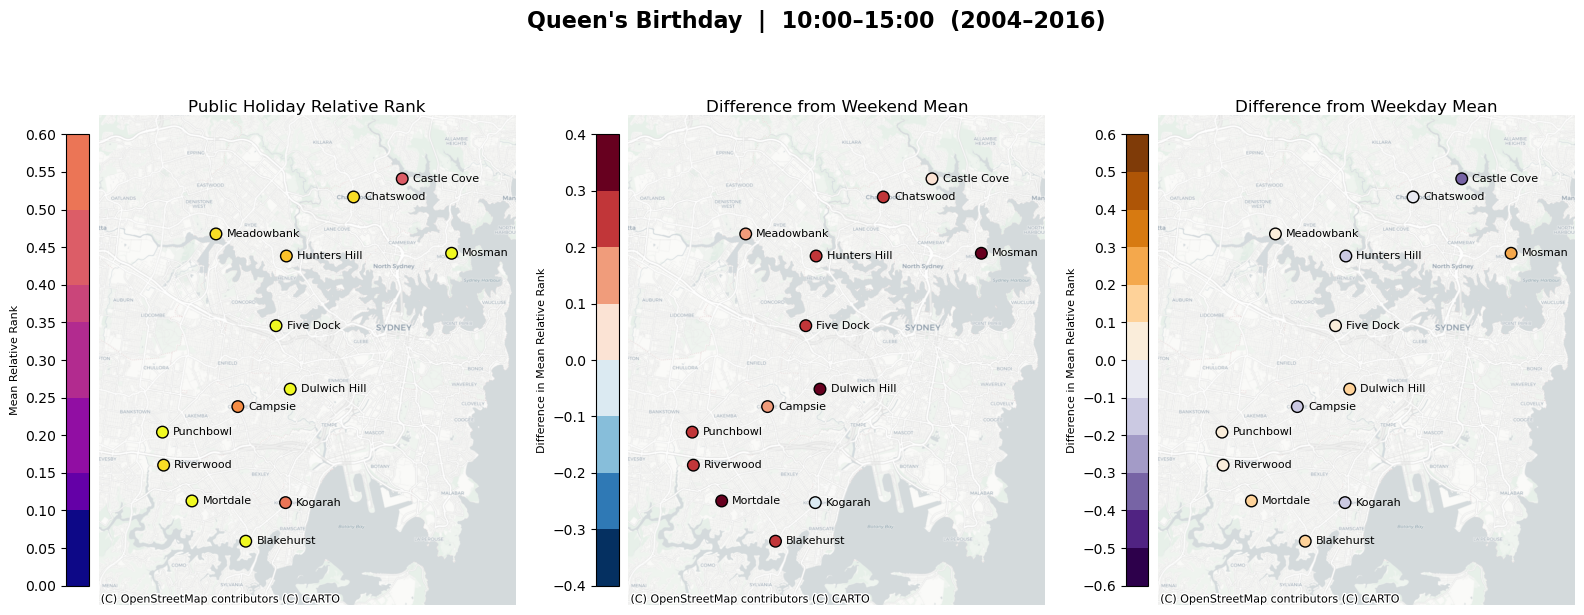

In [15]:
fig, gdf = map_ph_we_wd_block_combined_discrete(
    df=rank,
    info=info,
    holidays=["Queen's Birthday"],
    holiday_group_name="Queen's Birthday",
    block="10_15",
)
plt.show()

# Looping and saving

In [16]:
def batch_export_discrete_maps(
    df,
    info,
    holiday_batch=HOLIDAY_BATCH,
    fig_root=FIG_ROOT_SEMINAR,
):
    total = len(holiday_batch) * len(ALL_BLOCKS)
    done  = 0

    for group_name, holidays in holiday_batch:
        # Align holiday keys with the rename applied inside the mapping function
        holidays = [
            "Queen's Birthday" if h == "Monarch's Birthday" else h
            for h in holidays
        ]

        folder_name = group_name.replace("/", "-").replace("'", "")
        out_dir = fig_root / folder_name
        out_dir.mkdir(parents=True, exist_ok=True)

        for block in ALL_BLOCKS:
            out_path = out_dir / f"{block}.png"
            try:
                fig, _ = map_ph_we_wd_block_combined_discrete(
                    df=df,
                    info=info,
                    holidays=holidays,
                    holiday_group_name=group_name,
                    block=block,
                )
            except Exception as e:
                print(f"  [SKIP] {group_name} / {block} — {e}")
                done += 1
                continue

            fig.savefig(out_path, dpi=150, bbox_inches="tight")
            plt.close(fig)
            done += 1
            print(f"[{done}/{total}] Saved: {out_path}")

    print("\nDone.")

In [17]:
batch_export_discrete_maps(df=rank, info=info)

[1/30] Saved: /home/565/pv3484/aus_substation_electricity/data/figures/seminar_difference_maps/New Years Day/00_04.png
[2/30] Saved: /home/565/pv3484/aus_substation_electricity/data/figures/seminar_difference_maps/New Years Day/04_10.png
[3/30] Saved: /home/565/pv3484/aus_substation_electricity/data/figures/seminar_difference_maps/New Years Day/10_15.png
[4/30] Saved: /home/565/pv3484/aus_substation_electricity/data/figures/seminar_difference_maps/New Years Day/15_20.png
[5/30] Saved: /home/565/pv3484/aus_substation_electricity/data/figures/seminar_difference_maps/New Years Day/20_24.png
[6/30] Saved: /home/565/pv3484/aus_substation_electricity/data/figures/seminar_difference_maps/Australia Day/00_04.png
[7/30] Saved: /home/565/pv3484/aus_substation_electricity/data/figures/seminar_difference_maps/Australia Day/04_10.png
[8/30] Saved: /home/565/pv3484/aus_substation_electricity/data/figures/seminar_difference_maps/Australia Day/10_15.png
[9/30] Saved: /home/565/pv3484/aus_substation_el

In [18]:
info.columns.tolist()

['energy_asset',
 'Name',
 'Area',
 'Dwellings',
 'Persons',
 'Residential',
 'Commercial',
 'Industrial',
 'Primary Production',
 'Education',
 'Hospital/Medical',
 'Transport',
 'Parkland',
 'Water',
 'Other',
 'latitude',
 'longitude']